# Learning curves for undersampling (creditcard)

Two learning curves, both scored on **ROC-AUC** (insensitive to the class distribution) with 3-fold stratified CV, showing **train and test** so we can see where they converge:

1. **Full-distribution curve** — grow the training set at the original prior (sklearn `learning_curve`). This is the classic 'how much data do we need', but note it also drops minority points as it shrinks, which is what we do not want.
2. **Undersampling curve** — keep every positive and vary the negatives per positive (an imbalanced-learn `RandomUnderSampler` inside a Pipeline, swept via `sampling_strategy`). This isolates the effect of dropping only majority rows.

Random Forest and a histogram gradient-boosting model. creditcard is used with the benign class capped for a tractable demo; this is the starting point to iterate on, not the final run.

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '2')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import learning_curve, cross_validate, StratifiedKFold, train_test_split
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from functions.imbalanced_data import _fetch_openml
os.makedirs('../figures', exist_ok=True)

In [3]:
# full creditcard, benign capped to keep the demo tractable
X, y = _fetch_openml('creditcard', 1597)
y = pd.to_numeric(y).astype(int).to_numpy()
X = X.apply(pd.to_numeric).reset_index(drop=True).to_numpy()
pos = np.flatnonzero(y == 1)
neg = np.random.default_rng(0).choice(np.flatnonzero(y == 0), 50_000, replace=False)
keep = np.concatenate([pos, neg])
X, y = X[keep], y[keep]
learners = {'rf': RandomForestClassifier(n_estimators=200, random_state=0),
            'gbm': HistGradientBoostingClassifier(random_state=0)}
cv = StratifiedKFold(3, shuffle=True, random_state=0)
f'{len(y):,} rows, {y.sum()} positives ({100 * y.mean():.2f}%)'

'50,492 rows, 492 positives (0.97%)'

## Curve 1: full-distribution learning curve

Train (blue) and test (orange) ROC-AUC as the training set grows at the original prior. Bands are ±1 std across folds. Where the two curves meet, more data stops helping.

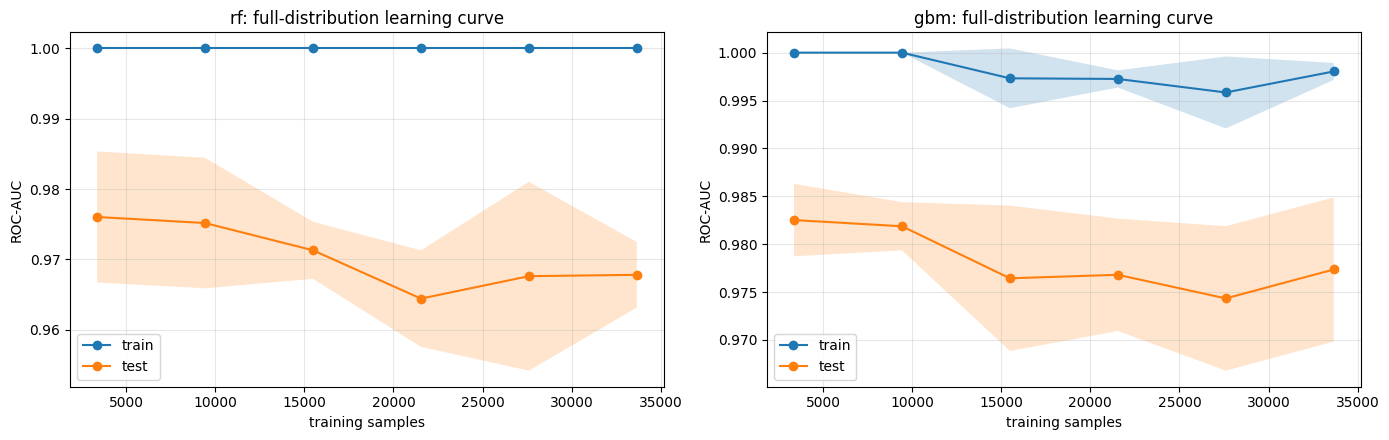

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sizes = np.linspace(0.1, 1.0, 6)
for ax, (name, est) in zip(axes, learners.items()):
    n, tr, te = learning_curve(est, X, y, train_sizes=sizes, cv=cv,
                               scoring='roc_auc', n_jobs=-1)
    for scores, lab in [(tr, 'train'), (te, 'test')]:
        m, s = scores.mean(1), scores.std(1)
        ax.plot(n, m, 'o-', label=lab)
        ax.fill_between(n, m - s, m + s, alpha=0.2)
    ax.set_xlabel('training samples'); ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{name}: full-distribution learning curve')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/lc_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Curve 2: undersampling curve (keep every positive)

Now keep all positives and vary the negatives per positive with `RandomUnderSampler` inside the Pipeline, so the undersampler is refit within each CV fold. Train and test ROC-AUC vs the ratio.

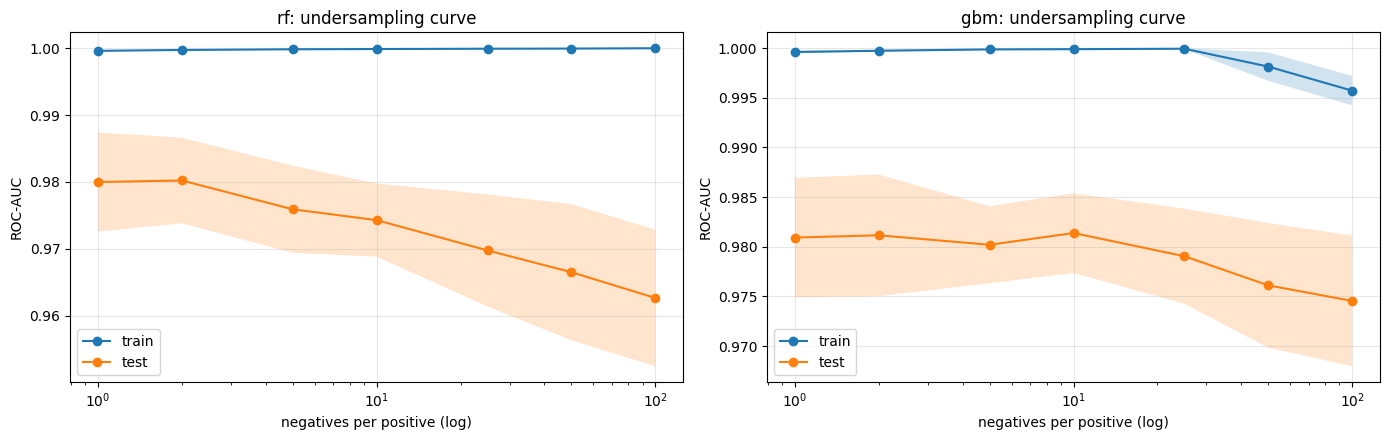

In [5]:
n_pos, n_neg = int(y.sum()), int((y == 0).sum())
ratios = [r for r in [1, 2, 5, 10, 25, 50, 100] if r <= n_neg // n_pos]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (name, est) in zip(axes, learners.items()):
    tr_m, tr_s, te_m, te_s = [], [], [], []
    for r in ratios:
        pipe = Pipeline([('rus', RandomUnderSampler(sampling_strategy=1.0 / r, random_state=0)),
                         ('clf', est)])
        out = cross_validate(pipe, X, y, cv=cv, scoring='roc_auc',
                             return_train_score=True, n_jobs=-1)
        tr_m.append(out['train_score'].mean()); tr_s.append(out['train_score'].std())
        te_m.append(out['test_score'].mean()); te_s.append(out['test_score'].std())
    for m, s, lab in [(tr_m, tr_s, 'train'), (te_m, te_s, 'test')]:
        m, s = np.array(m), np.array(s)
        ax.plot(ratios, m, 'o-', label=lab)
        ax.fill_between(ratios, m - s, m + s, alpha=0.2)
    ax.set_xscale('log'); ax.set_xlabel('negatives per positive (log)')
    ax.set_ylabel('ROC-AUC'); ax.set_title(f'{name}: undersampling curve')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/lc_undersample.png', dpi=150, bbox_inches='tight')
plt.show()

## Reading these

Curve 1 says how much of the full-distribution data is actually needed before ROC-AUC plateaus and train/test converge. Curve 2 says how far we can drop the majority (keeping every positive) before test ROC-AUC starts to fall. The gap between train and test on either curve is the overfitting signal. This is the starting point Sole asked for; next we would add the speed / calibration comparison at a chosen operating point, and extend beyond creditcard.